## Imports

In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import matplotlib as mpl
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from sklearn.mixture import GaussianMixture
import pandas as pd
import os
import pickle
from pathlib import Path
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
import datetime
plt.rcParams['text.usetex'] = True

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
obs_dir = '/global/cfs/projectdirs/m1657/avarble/cor/combomet/'
files_hr = sorted(glob.glob(obs_dir+'*hourly*.nc'))
print(files_hr)

['/global/cfs/projectdirs/m1657/avarble/cor/combomet/COR_hourly_aerosol_meteorology_201810.nc', '/global/cfs/projectdirs/m1657/avarble/cor/combomet/COR_hourly_aerosol_meteorology_201811.nc', '/global/cfs/projectdirs/m1657/avarble/cor/combomet/COR_hourly_aerosol_meteorology_201812.nc', '/global/cfs/projectdirs/m1657/avarble/cor/combomet/COR_hourly_aerosol_meteorology_201901.nc', '/global/cfs/projectdirs/m1657/avarble/cor/combomet/COR_hourly_aerosol_meteorology_201902.nc', '/global/cfs/projectdirs/m1657/avarble/cor/combomet/COR_hourly_aerosol_meteorology_201903.nc', '/global/cfs/projectdirs/m1657/avarble/cor/combomet/COR_hourly_aerosol_meteorology_201904.nc']


In [3]:
# Define the variables you want to keep
variables = ['Nccn8','Nccn4']

# Option 1: Using open_mfdataset with preprocess
def keep_vars(ds):
    return ds[variables]

ds_ccn = xr.open_mfdataset(files_hr, combine='by_coords', preprocess=keep_vars)


In [4]:
# Define the variables you want to keep
variables = ['Nccn8_fit','Nccn4_fit']

# Option 1: Using open_mfdataset with preprocess
def keep_vars(ds):
    return ds[variables]

ds_ccn_fit = xr.open_mfdataset(files_hr, combine='by_coords', preprocess=keep_vars)


In [5]:
# Define the variables you want to keep
variables = ['N15_smps','N50_smps']

# Option 1: Using open_mfdataset with preprocess
def keep_vars(ds):
    return ds[variables]

ds_smps = xr.open_mfdataset(files_hr, combine='by_coords', preprocess=keep_vars)

In [6]:
# Define the variables you want to keep
variables = ['Ncpc']

# Option 1: Using open_mfdataset with preprocess
def keep_vars(ds):
    return ds[variables]

ds_cpc = xr.open_mfdataset(files_hr, combine='by_coords', preprocess=keep_vars)

In [7]:
ds_cpc

<xarray.Dataset> Size: 61kB
Dimensions:   (time_cpc: 5095)
Coordinates:
  * time_cpc  (time_cpc) datetime64[ns] 41kB 2018-10-01 ... 2019-05-01
Data variables:
    Ncpc      (time_cpc) float32 20kB dask.array<chunksize=(745,), meta=np.ndarray>
Attributes:
    Title:        COR hourly meteorological and aerosol quantities
    Description:  Data from ARM interpolated sonde, surface met station, MWR,...
    Created on:   Sat Jul 19 11:39:01 2025
    Contact:      Adam Varble, adam.varble@pnnl.gov

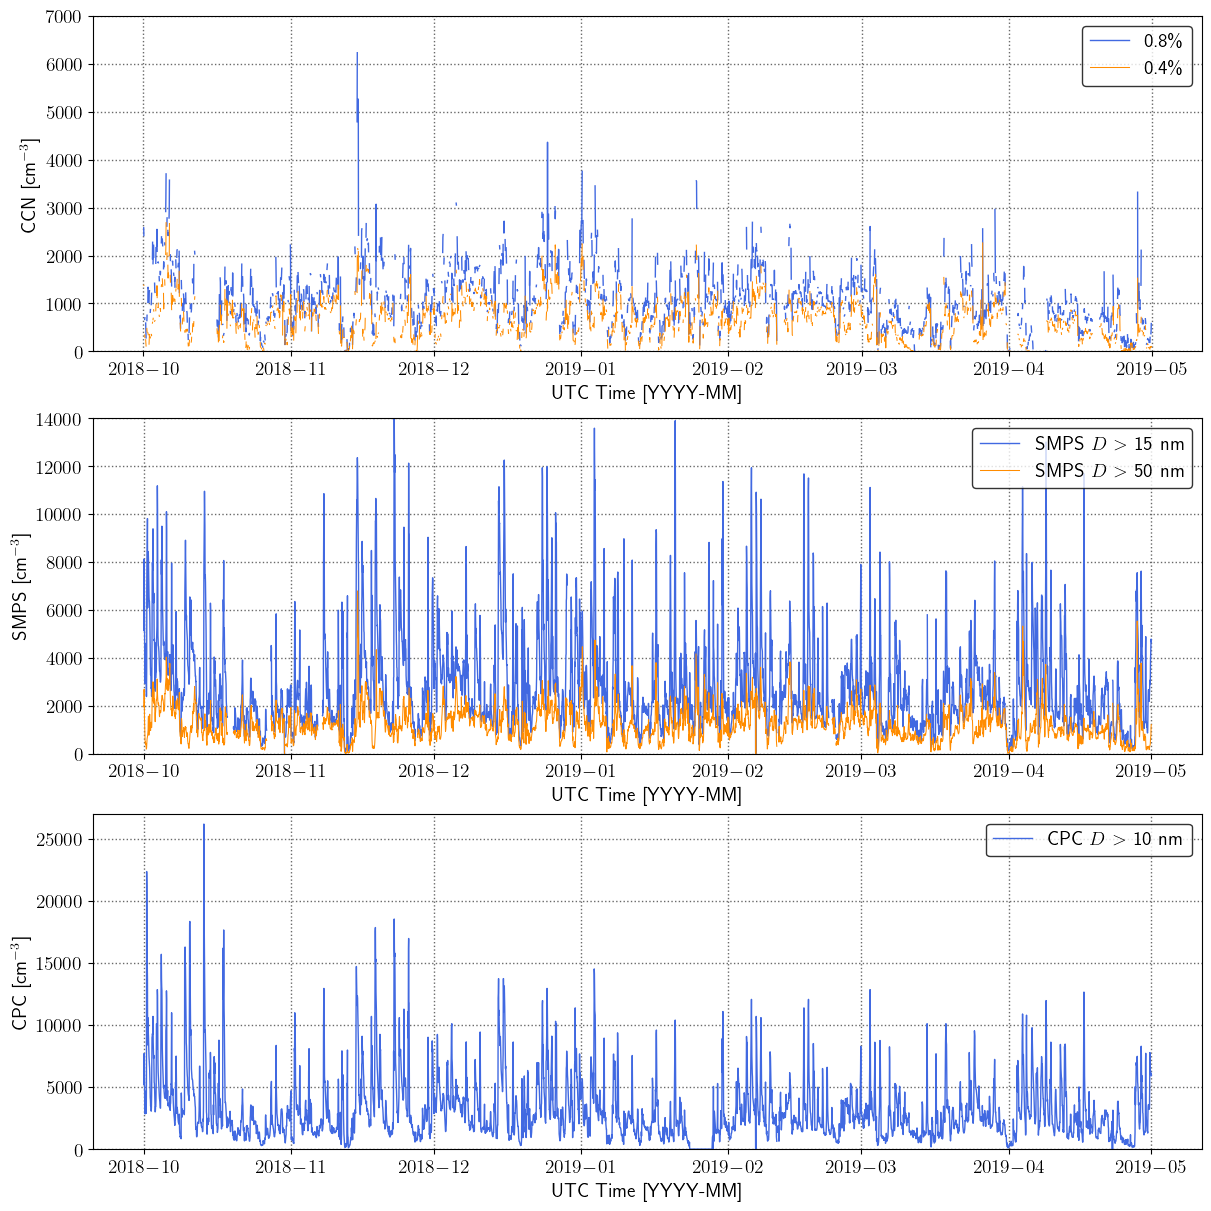

In [8]:
fig = plt.figure(figsize=(12,12),constrained_layout=True)
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)
axlist = [ax1,ax2,ax3]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('UTC Time [YYYY-MM]',fontsize=Fontsize)

ax1.set_ylabel('CCN [cm$^{-3}$]',fontsize=Fontsize)
ax2.set_ylabel('SMPS [cm$^{-3}$]',fontsize=Fontsize)
ax3.set_ylabel('CPC [cm$^{-3}$]',fontsize=Fontsize)
    
ax1.plot(ds_ccn['time_ccn'],ds_ccn['Nccn8'],lw=1,label='0.8\%',c='royalblue')
ax1.plot(ds_ccn['time_ccn'],ds_ccn['Nccn4'],lw=0.75,label='0.4\%',c='darkorange')

#ax1.plot(ds_ccn_fit['time_ccn'],ds_ccn_fit['Nccn8_fit'],lw=1,label='0.8\%',c='navy')
#ax1.plot(ds_ccn_fit['time_ccn'],ds_ccn_fit['Nccn4_fit'],lw=0.75,label='0.4\%',c='red')

ax1.legend(loc='upper right',fontsize=Fontsize,edgecolor='k')
ax1.set_ylim(0,7000)

ax2.plot(ds_smps['time_smps'],ds_smps['N15_smps'],lw=1,label='SMPS $D$ $>$ 15 nm',c='royalblue')
ax2.plot(ds_smps['time_smps'],ds_smps['N50_smps'],lw=0.75,label='SMPS $D$ $>$ 50 nm',c='darkorange')
ax2.legend(loc='upper right',fontsize=Fontsize,edgecolor='k')
ax2.set_ylim(0,14000)

ax3.plot(ds_cpc['time_cpc'],ds_cpc['Ncpc'],lw=1,label='CPC $D$ $>$ 10 nm',c='royalblue')
ax3.legend(loc='upper right',fontsize=Fontsize,edgecolor='k')
ax3.set_ylim(0,27000)

plt.show()
plt.close()

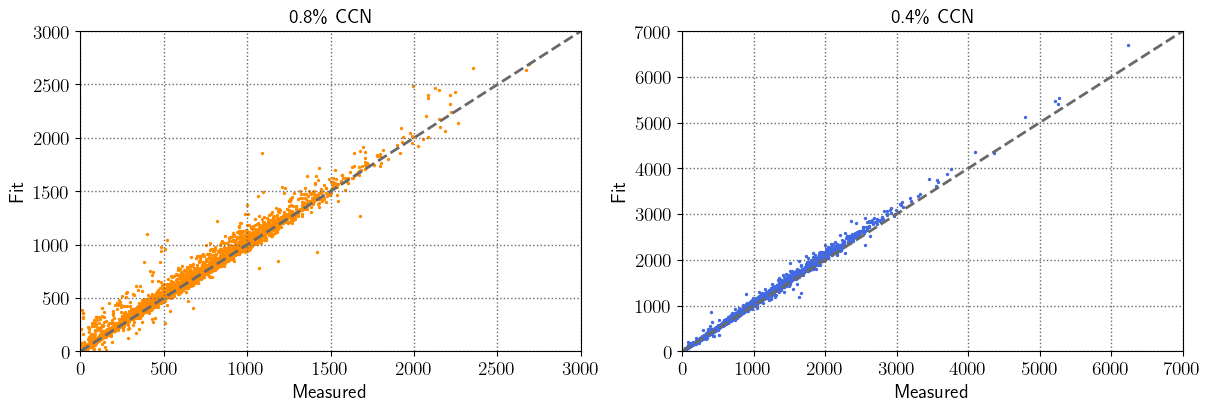

In [9]:
fig = plt.figure(figsize=(12,4),constrained_layout=True)
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
axlist = [ax1,ax2]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('Measured',fontsize=Fontsize)
    ax.set_ylabel('Fit',fontsize=Fontsize)

ax1.plot([0,3000],[0,3000],lw=2,ls='dashed',c='dimgrey')
ax2.plot([0,7000],[0,7000],lw=2,ls='dashed',c='dimgrey')


ax1.set_xlim(0,3000)
ax1.set_ylim(0,3000)
ax2.set_xlim(0,7000)
ax2.set_ylim(0,7000)

ax1.set_title('0.8\% CCN',fontsize=Fontsize)
ax2.set_title('0.4\% CCN',fontsize=Fontsize)

ax1.scatter(ds_ccn['Nccn4'],ds_ccn_fit['Nccn4_fit'],s=2,c='darkorange')
ax2.scatter(ds_ccn['Nccn8'],ds_ccn_fit['Nccn8_fit'],s=2,c='royalblue')


plt.show()
plt.close()

# WRF

In [37]:
import os
from fnmatch import fnmatch
from concurrent.futures import ThreadPoolExecutor

base_path = '/global/homes/m/mckenna/cacti_data/wrf/output'

def search_date_dir(date_dir):
    """Search a single date directory for 3D WRF output files"""
    matches = []
    for f in os.listdir(date_dir):
        if fnmatch(f, 'wrfout_d02*_3d*'):
            matches.append(os.path.join(date_dir, f))
    return sorted(matches)

# Get all date directories
date_dirs = sorted([
    os.path.join(base_path, d) 
    for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))
])

print(f"Found {len(date_dirs)} date directories")
print(f"First: {date_dirs[0]}")
print(f"Last:  {date_dirs[-1]}")

# Search in parallel
with ThreadPoolExecutor(max_workers=16) as executor:
    results = list(executor.map(search_date_dir, date_dirs))

# Flatten list of lists
wrf_3d_files = sorted([f for sublist in results for f in sublist])

print(f"Found {len(wrf_3d_files)} 3D WRF files total")
print(f"First: {wrf_3d_files[0]}")
print(f"Last:  {wrf_3d_files[-1]}")

wrf_3d_files = wrf_3d_files[::4]

Found 200 date directories
First: /global/homes/m/mckenna/cacti_data/wrf/output/2018-10-15
Last:  /global/homes/m/mckenna/cacti_data/wrf/output/AMF1_profiles
Found 76033 3D WRF files total
First: /global/homes/m/mckenna/cacti_data/wrf/output/2018-10-15/wrfout_d02_2018-10-15_00:00:00_3d
Last:  /global/homes/m/mckenna/cacti_data/wrf/output/2019-05-01/wrfout_d02_2019-05-01_00:00:00_3d


In [38]:
print(len(wrf_3d_files))

19009


In [10]:
from datetime import datetime  # import the CLASS not the module

# Get the AMF lat/lon from a single met
met_file = '/global/cfs/projectdirs/m1657/avarble/cor/met/cormetM1.b1.20190211.000000.cdf'
ds = xr.open_dataset(met_file)
amf_lon = ds['lon'].values.item()  # scalar
amf_lat = ds['lat'].values.item()  # scalar
ds.close()

# Get the lat/lon grid only to identify point closest to the AMF site
variables_latlon = ['XLONG', 'XLAT']

def keep_vars_latlon(ds):
    return ds[variables_latlon]

# Use any single file just to get the grid
ds = xr.open_mfdataset(wrf_3d_files[0], preprocess=keep_vars_latlon)
lon = ds['XLONG'].values.squeeze()  # shape: (south_north, west_east)
lat = ds['XLAT'].values.squeeze()   # shape: (south_north, west_east)
ds.close()

# Find the closest grid point using Euclidean distance
dist = np.sqrt((lon - amf_lon)**2 + (lat - amf_lat)**2)
lat_id, lon_id = np.unravel_index(np.argmin(dist), dist.shape)
print(f"Closest WRF point: lat_id={lat_id}, lon_id={lon_id}")
print(f"WRF lat/lon: {lat[lat_id, lon_id]:.4f}, {lon[lat_id, lon_id]:.4f}")
print(f"AMF lat/lon: {amf_lat:.4f}, {amf_lon:.4f}")

# Variables to extract
variables = ['CAC_WA', 'CAC_T', 'CAC_P', 'CAC_QV', 'Times']

def keep_vars(ds):
    return ds[variables]

# Storage for results
results = []

Rd = 287.04

for file in wrf_3d_files:
    print(file)
    ds = xr.open_mfdataset(file, preprocess=keep_vars)

    # Parse time from WRF byte string
    time_bytes = ds['Times'].values.squeeze().item()  # extract scalar from numpy array
    time_str = time_bytes.decode('utf-8')             # '2018-10-15_00:00:00'
    time_dt = datetime.strptime(time_str, '%Y-%m-%d_%H:%M:%S')  # datetime object

    # Extract surface values at the AMF point
    nwfa     = ds['CAC_WA'].values.squeeze()[0, lat_id, lon_id]  # /kg
    temp_K   = ds['CAC_T'].values.squeeze()[0, lat_id, lon_id] - 273.15  # deg C (was K)
    qv       = ds['CAC_QV'].values.squeeze()[0, lat_id, lon_id] * 1.e-3  # kg/kg
    pressure = ds['CAC_P'].values.squeeze()[0, lat_id, lon_id]  # Pa
    ds.close()

    # Compute air density
    Tv = (temp_K + 273.15) * (1. + 0.61 * qv)  # Virtual temperature in K
    rho_air = pressure / (Rd * Tv)              # kg/m^3

    # Convert NWFA from /kg to /cc
    nwfa_cc = nwfa * rho_air * 1.e-6

    results.append({'time': time_dt, 'nwfa': nwfa_cc})

    print(f"{time_dt} -> nwfa = {nwfa_cc:.4f} /cc")

    print(aaaaa)

Closest WRF point: lat_id=244, lon_id=236
WRF lat/lon: -32.1194, -64.7130
AMF lat/lon: -32.1264, -64.7284
/global/homes/m/mckenna/cacti_data/wrf/output/2018-10-15/wrfout_d02_2018-10-15_00:00:00_3d
2018-10-15 00:00:00 -> nwfa = 4366.0138 /cc


NameError: name 'aaaaa' is not defined

In [11]:
import xarray as xr
import numpy as np
from datetime import datetime
from multiprocessing import Pool
from datetime import datetime
from tqdm import tqdm

In [39]:
# Get the AMF lat/lon from a single met
met_file = '/global/cfs/projectdirs/m1657/avarble/cor/met/cormetM1.b1.20190211.000000.cdf'
ds = xr.open_dataset(met_file)
amf_lon = ds['lon'].values.item()  # scalar
amf_lat = ds['lat'].values.item()  # scalar
ds.close()

# Get the lat/lon grid only to identify point closest to the AMF site
variables_latlon = ['XLONG', 'XLAT']

def keep_vars_latlon(ds):
    return ds[variables_latlon]

# Use any single file just to get the grid
ds = xr.open_mfdataset(wrf_3d_files[0], preprocess=keep_vars_latlon)
lon = ds['XLONG'].values.squeeze()  # shape: (south_north, west_east)
lat = ds['XLAT'].values.squeeze()   # shape: (south_north, west_east)
ds.close()

# Find the closest grid point using Euclidean distance
dist = np.sqrt((lon - amf_lon)**2 + (lat - amf_lat)**2)
lat_id, lon_id = np.unravel_index(np.argmin(dist), dist.shape)
print(f"Closest WRF point: lat_id={lat_id}, lon_id={lon_id}")
print(f"WRF lat/lon: {lat[lat_id, lon_id]:.4f}, {lon[lat_id, lon_id]:.4f}")
print(f"AMF lat/lon: {amf_lat:.4f}, {amf_lon:.4f}")


def keep_vars(ds):
    return ds[variables]

Rd = 287.04
variables = ['CAC_WA', 'CAC_T', 'CAC_P', 'CAC_QV', 'Times']

def process_file(args):
    file, lat_id, lon_id = args
    try:
        ds = xr.open_dataset(file)[variables]
        
        # Parse time
        time_bytes = ds['Times'].values.squeeze().item()
        time_str = time_bytes.decode('utf-8')
        time_dt = datetime.strptime(time_str, '%Y-%m-%d_%H:%M:%S')
        
        # Extract surface values at AMF point
        nwfa     = ds['CAC_WA'].values.squeeze()[0, lat_id, lon_id]
        temp_K   = ds['CAC_T'].values.squeeze()[0, lat_id, lon_id] - 273.15
        qv       = ds['CAC_QV'].values.squeeze()[0, lat_id, lon_id] * 1.e-3
        pressure = ds['CAC_P'].values.squeeze()[0, lat_id, lon_id]
        ds.close()
        
        # Compute air density and convert nwfa
        Tv = (temp_K + 273.15) * (1. + 0.61 * qv)
        rho_air = pressure / (Rd * Tv)
        nwfa_cc = nwfa * rho_air * 1.e-6
        
        return {'time': time_dt, 'nwfa': nwfa_cc}
    
    except Exception as e:
        print(f"Error processing {file}: {e}")
        return None

# Pack arguments
args = [(file, lat_id, lon_id) for file in wrf_3d_files]

# Run in parallel
with Pool(processes=128) as pool:
    results = list(tqdm(
        pool.imap(process_file, args),
        total=len(args),
        desc='Processing WRF files'
    ))

# Filter, sort, unpack
results = sorted([r for r in results if r is not None], key=lambda x: x['time'])
times = [r['time'] for r in results]
nwfa  = [r['nwfa'] for r in results]

print(f"Processed {len(results)} files successfully")
print(f"Time range: {times[0]} to {times[-1]}")

Closest WRF point: lat_id=244, lon_id=236
WRF lat/lon: -32.1194, -64.7130
AMF lat/lon: -32.1264, -64.7284


Processing WRF files: 100%|██████████| 19009/19009 [07:08<00:00, 44.38it/s] 


Processed 19009 files successfully
Time range: 2018-10-15 00:00:00 to 2019-05-01 00:00:00


In [40]:
out_dict = {'time':times,'nwfa':nwfa}
file_name = 'WRF_AMF_NWFA.p'
with open(file_name, 'wb') as f:
    pickle.dump(out_dict, f)

In [10]:
read_path = './'
file_name = 'WRF_AMF_NWFA.p'
# Load the dictionary
with open(read_path+file_name, 'rb') as f:
    wrf_dict = pickle.load(f)

In [11]:
import pandas as pd

# Convert to DataFrame
df = pd.DataFrame(wrf_dict)
df = df.set_index('time')
df = df.sort_index()

# Compute hourly averages - average whatever samples exist in each hour
df_hourly = df.resample('1h').mean()

print(df_hourly)
print(f"Total hourly values: {len(df_hourly)}")
print(f"Non-NaN hourly values: {df_hourly['nwfa'].notna().sum()}")

                            nwfa
time                            
2018-10-15 00:00:00  4427.433542
2018-10-15 01:00:00  4453.174368
2018-10-15 02:00:00  4377.183236
2018-10-15 03:00:00  4140.303982
2018-10-15 04:00:00  4148.318101
...                          ...
2019-04-30 20:00:00  1374.880269
2019-04-30 21:00:00  1511.508041
2019-04-30 22:00:00  1602.338452
2019-04-30 23:00:00  1652.413421
2019-05-01 00:00:00  1696.329621

[4753 rows x 1 columns]
Total hourly values: 4753
Non-NaN hourly values: 4753


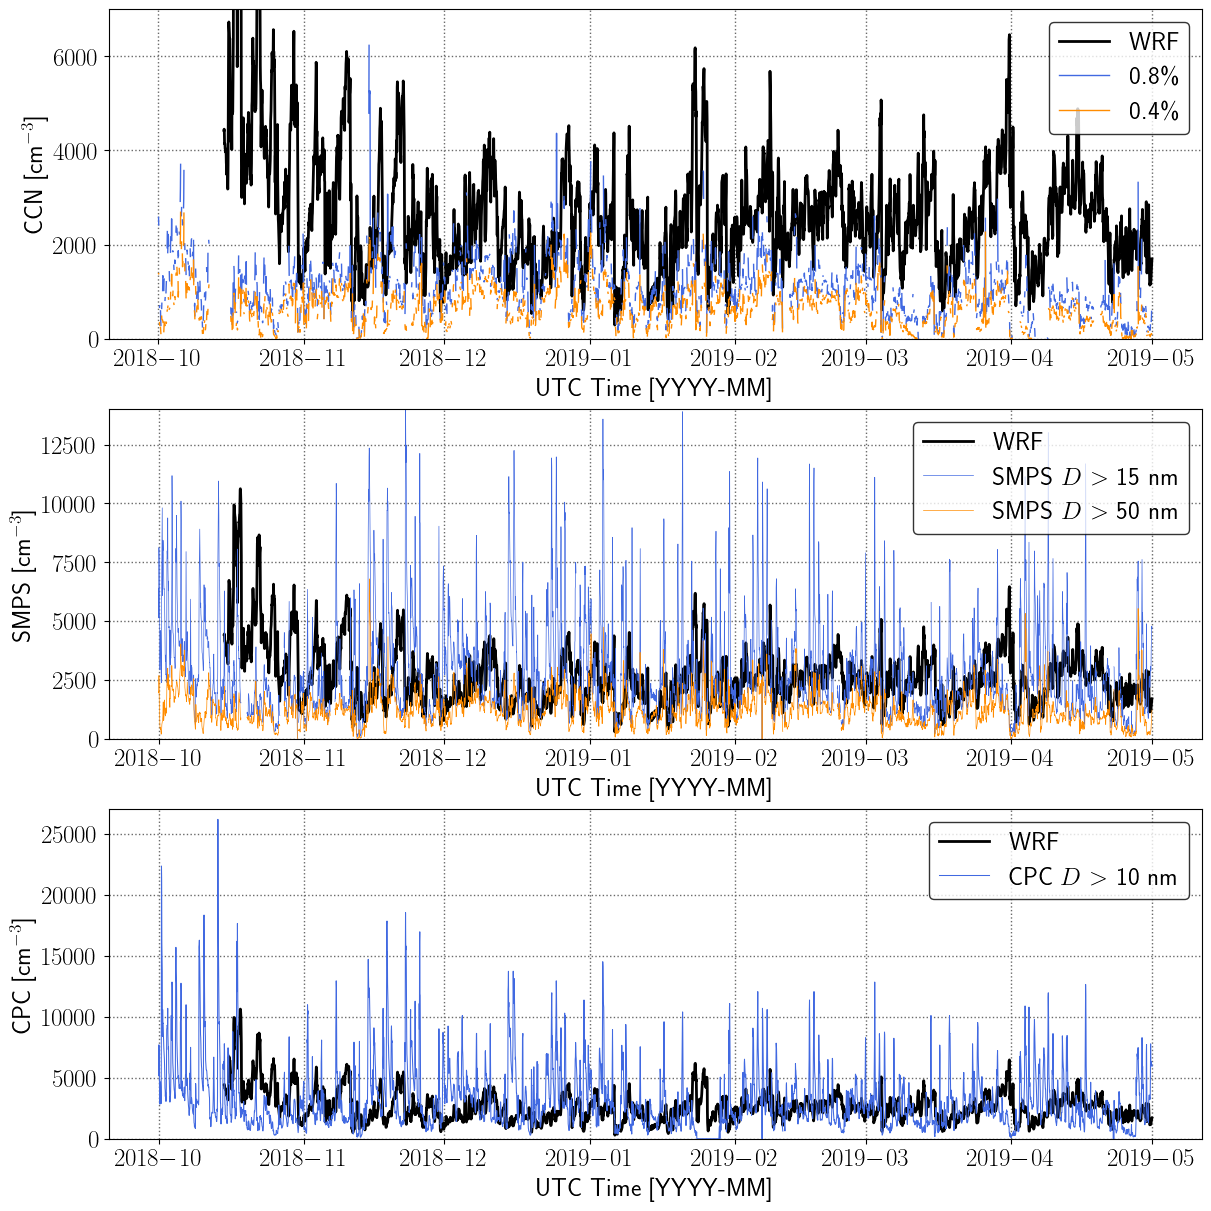

In [13]:
fig = plt.figure(figsize=(12,12),constrained_layout=True)
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)
axlist = [ax1,ax2,ax3]
Fontsize=18
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('UTC Time [YYYY-MM]',fontsize=Fontsize)

ax1.set_ylabel('CCN [cm$^{-3}$]',fontsize=Fontsize)
ax2.set_ylabel('SMPS [cm$^{-3}$]',fontsize=Fontsize)
ax3.set_ylabel('CPC [cm$^{-3}$]',fontsize=Fontsize)



for ax in axlist:
    ax.plot(df_hourly.index, df_hourly['nwfa'],lw=2,c='k',label='WRF')

ax1.plot(ds_ccn['time_ccn'],ds_ccn['Nccn8'],lw=1,label='0.8\%',c='royalblue')
ax1.plot(ds_ccn['time_ccn'],ds_ccn['Nccn4'],lw=1,label='0.4\%',c='darkorange')
ax1.legend(loc='upper right',fontsize=Fontsize,edgecolor='k')
ax1.set_ylim(0,7000)

ax2.plot(ds_smps['time_smps'],ds_smps['N15_smps'],lw=0.5,label='SMPS $D$ $>$ 15 nm',c='royalblue')
ax2.plot(ds_smps['time_smps'],ds_smps['N50_smps'],lw=0.5,label='SMPS $D$ $>$ 50 nm',c='darkorange')
ax2.legend(loc='upper right',fontsize=Fontsize,edgecolor='k')
ax2.set_ylim(0,14000)

ax3.plot(ds_cpc['time_cpc'],ds_cpc['Ncpc'],lw=0.75,label='CPC $D$ $>$ 10 nm',c='royalblue')
ax3.legend(loc='upper right',fontsize=Fontsize,edgecolor='k')
ax3.set_ylim(0,27000)



plt.show()
plt.close()

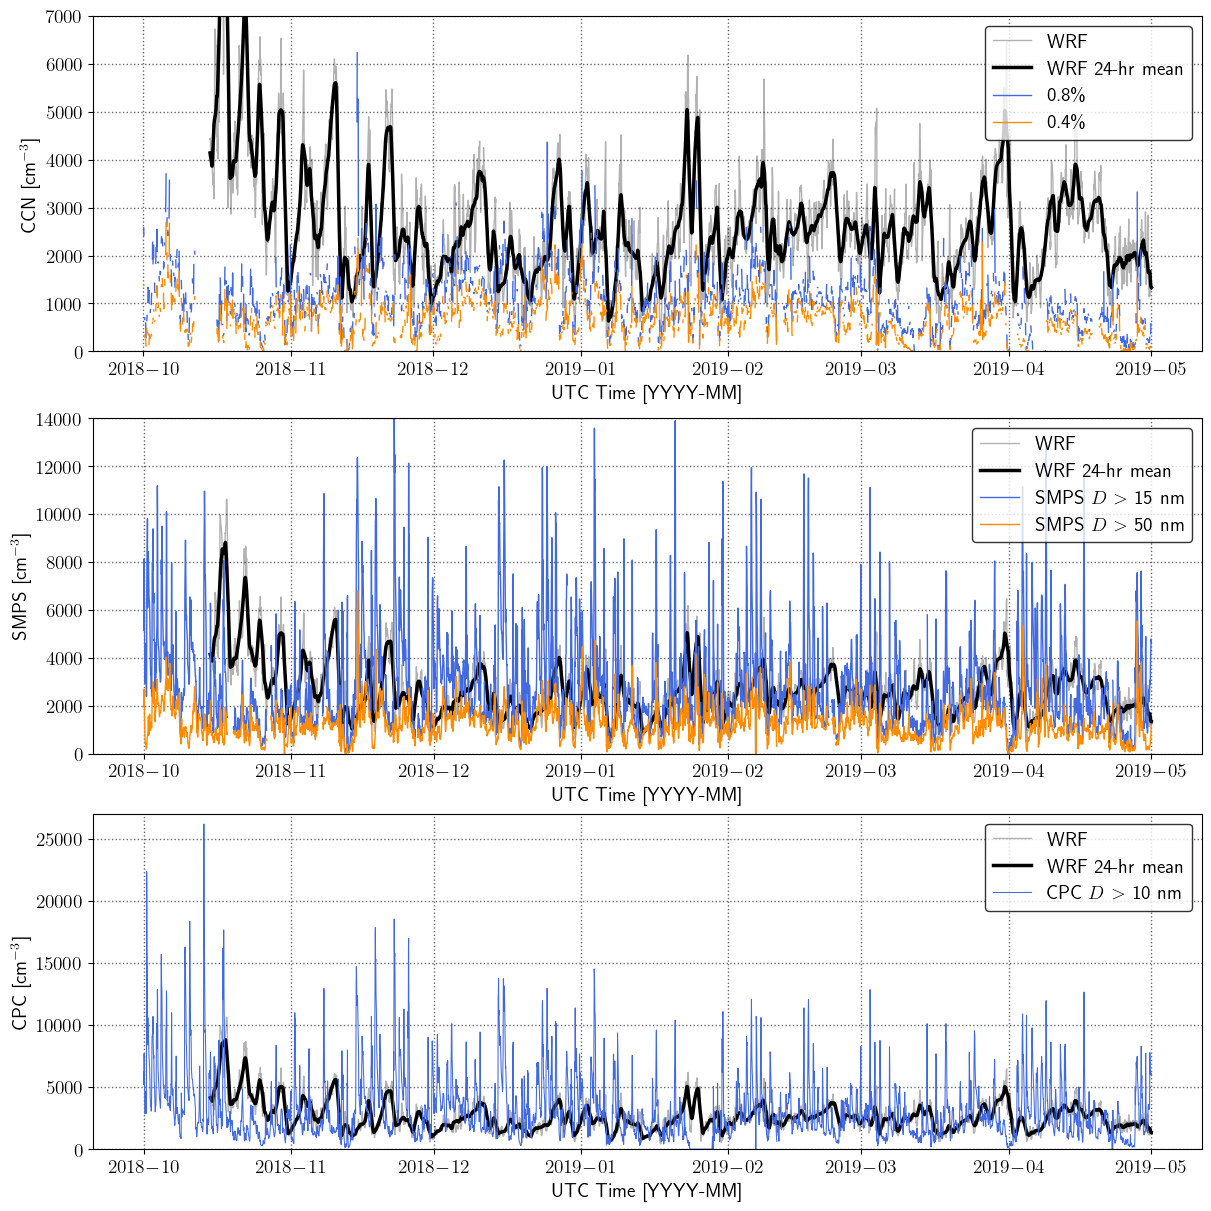

In [46]:
# Compute running mean (e.g. 24-hour window)
window = 24  # hours
df_hourly['nwfa_rolling'] = df_hourly['nwfa'].rolling(window=window, center=True, min_periods=1).mean()

fig = plt.figure(figsize=(12,12), constrained_layout=True)
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)
axlist = [ax1, ax2, ax3]
Fontsize = 14
for ax in axlist:
    ax.grid(which='both', lw=1, c='dimgrey', ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('UTC Time [YYYY-MM]', fontsize=Fontsize)

ax1.set_ylabel('CCN [cm$^{-3}$]', fontsize=Fontsize)
ax2.set_ylabel('SMPS [cm$^{-3}$]', fontsize=Fontsize)
ax3.set_ylabel('CPC [cm$^{-3}$]', fontsize=Fontsize)

for ax in axlist:
    ax.plot(df_hourly.index, df_hourly['nwfa'],         lw=1,   c='k', alpha=0.3, label='WRF')
    ax.plot(df_hourly.index, df_hourly['nwfa_rolling'], lw=2.5, c='k', alpha=1.0, label=f'WRF {window}-hr mean')

ax1.plot(ds_ccn['time_ccn'], ds_ccn['Nccn8'], lw=1, label='0.8\%', c='royalblue')
ax1.plot(ds_ccn['time_ccn'], ds_ccn['Nccn4'], lw=1, label='0.4\%', c='darkorange')
ax1.legend(loc='upper right', fontsize=Fontsize, edgecolor='k')
ax1.set_ylim(0, 7000)

ax2.plot(ds_smps['time_smps'], ds_smps['N15_smps'], lw=1, label='SMPS $D$ $>$ 15 nm', c='royalblue')
ax2.plot(ds_smps['time_smps'], ds_smps['N50_smps'], lw=1, label='SMPS $D$ $>$ 50 nm', c='darkorange')
ax2.legend(loc='upper right', fontsize=Fontsize, edgecolor='k')
ax2.set_ylim(0, 14000)

ax3.plot(ds_cpc['time_cpc'], ds_cpc['Ncpc'], lw=0.75, label='CPC $D$ $>$ 10 nm', c='royalblue')
ax3.legend(loc='upper right', fontsize=Fontsize, edgecolor='k')
ax3.set_ylim(0, 27000)

plt.show()
plt.close()

In [49]:
# Compute running mean for WRF
window = 24  # hours
df_hourly['nwfa_rolling'] = df_hourly['nwfa'].rolling(window=window, center=True, min_periods=1).mean()

# Compute running mean for observations (xarray needs dimension name)
ds_ccn['Nccn8_rolling']    = ds_ccn['Nccn8'].rolling(time_ccn=window,   center=True, min_periods=1).mean()
ds_ccn['Nccn4_rolling']    = ds_ccn['Nccn4'].rolling(time_ccn=window,   center=True, min_periods=1).mean()
ds_smps['N15_smps_rolling'] = ds_smps['N15_smps'].rolling(time_smps=window, center=True, min_periods=1).mean()
ds_smps['N50_smps_rolling'] = ds_smps['N50_smps'].rolling(time_smps=window, center=True, min_periods=1).mean()
ds_cpc['Ncpc_rolling']     = ds_cpc['Ncpc'].rolling(time_cpc=window,    center=True, min_periods=1).mean()

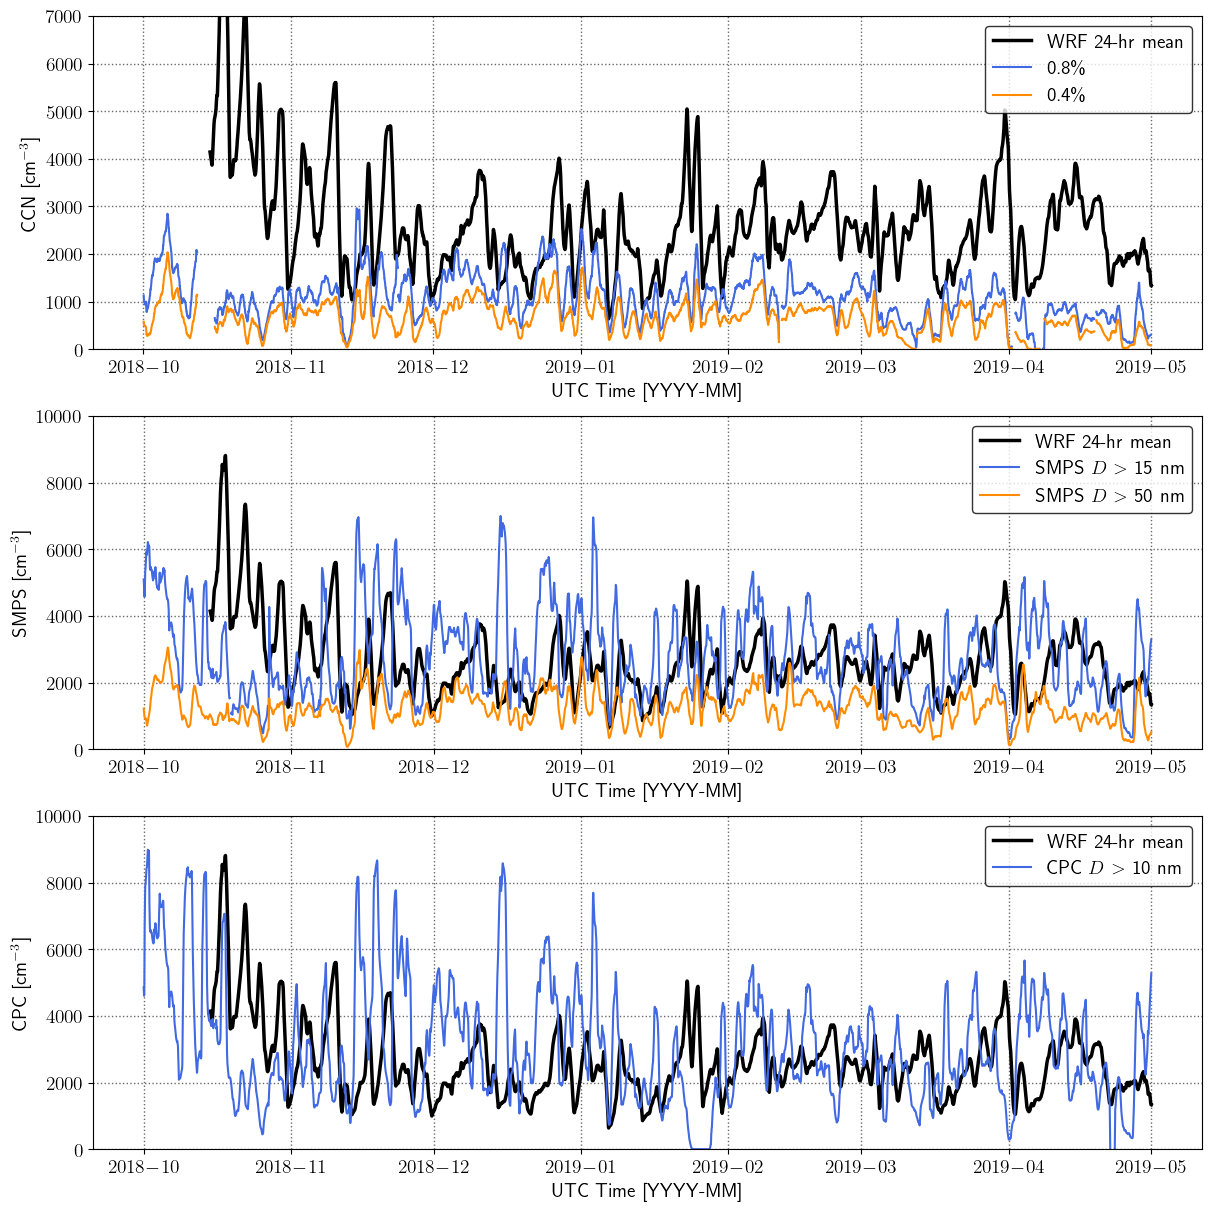

In [52]:
fig = plt.figure(figsize=(12,12), constrained_layout=True)
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)
axlist = [ax1, ax2, ax3]
Fontsize = 14
for ax in axlist:
    ax.grid(which='both', lw=1, c='dimgrey', ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('UTC Time [YYYY-MM]', fontsize=Fontsize)

ax1.set_ylabel('CCN [cm$^{-3}$]', fontsize=Fontsize)
ax2.set_ylabel('SMPS [cm$^{-3}$]', fontsize=Fontsize)
ax3.set_ylabel('CPC [cm$^{-3}$]', fontsize=Fontsize)

for ax in axlist:
    ax.plot(df_hourly.index, df_hourly['nwfa_rolling'], lw=2.5, c='k', label=f'WRF {window}-hr mean')

ax1.plot(ds_ccn['time_ccn'], ds_ccn['Nccn8_rolling'], lw=1.5, label='0.8\%', c='royalblue')
ax1.plot(ds_ccn['time_ccn'], ds_ccn['Nccn4_rolling'], lw=1.5, label='0.4\%', c='darkorange')
ax1.legend(loc='upper right', fontsize=Fontsize, edgecolor='k')
ax1.set_ylim(0, 7000)

ax2.plot(ds_smps['time_smps'], ds_smps['N15_smps_rolling'], lw=1.5, label='SMPS $D$ $>$ 15 nm', c='royalblue')
ax2.plot(ds_smps['time_smps'], ds_smps['N50_smps_rolling'], lw=1.5, label='SMPS $D$ $>$ 50 nm', c='darkorange')
ax2.legend(loc='upper right', fontsize=Fontsize, edgecolor='k')
ax2.set_ylim(0, 10000)

ax3.plot(ds_cpc['time_cpc'], ds_cpc['Ncpc_rolling'], lw=1.5, label='CPC $D$ $>$ 10 nm', c='royalblue')
ax3.legend(loc='upper right', fontsize=Fontsize, edgecolor='k')
ax3.set_ylim(0, 10000)

plt.show()
plt.close()